 # 학습 내용
- AI Agent
- Vision Agent
- 간단한 Vison Agent 구현 (단순 반사 에이전트)
- Gradio를 이용한 웹 서비스 구현
- 시각-언어-행동 통합 Agent 구현 (모델 기반 반사 에이전트)
- Streamlit을 이용한 웹 서비스구현
- 비디오 이해를 위한 Vison Agent 구현 (모델 기반 반사 에이전트)
- Gradio를 이용한 웹 서비스 구현
- Stablediffusion 기반 이미지 생성
- 이미지 생성 Agent 구현
- Streamlit을 이용한 웹 서비스구현

 # Vision Agent 개요
- 많은 AI 에이전트가 NLP를 통한 언어 처리에 중점을 두는 반면, 비전 AI 에이전트는 **컴퓨터 비전을 통합하여 시각 데이터를 처리**
  - Ultralytics YOLO11과 같은 고급 컴퓨터 비전 모델을 사용하여 보다 정밀한 이미지 분석을 수행
- 자율 주행 차량의 비전 AI 에이전트 작동 예시
  - 인식
    - 자율주행차의 비전 AI 에이전트는 차량에 설치된 카메라와 센서에서 시각 데이터를 수집
    - 데이터에는 다른 차량, 보행자, 교통 신호, 도로 표지판 등 주변 환경의 이미지와 비디오가 포함

  - 의사 결정
    - 시각적 데이터를 처리
    - 자동차나 보행자와 같은 물체를 식별하고 장애물이나 갑작스러운 차선 변경을 감지하며 교통 흐름 및 신호 상태와 같은 패턴을 인식
    - 이를 통해 차량이 도로 상황을 실시간으로 파악

  - 행동
    - 분석 결과를 바탕으로 장애물을 피하기 위해 스티어링을 조작하거나 속도를 조절하거나 빨간불에 정지하는 등의 조치를 취함
    - 안전하고 효율적인 운전을 보장하기 위해 신속하게 동작

### 비전 AI 에이전트 유형
- 단순 반사 에이전트
  - 가장 기본적인 유형의 AI 에이전트
  - 과거 기록이나 미래의 결과를 고려하지 않고 순전히 현재 상황에 따라 미리 정의된 동작으로 특정 입력에 응답
  - 일반적으로 간단한 "if-then" 규칙을 사용하여 행동을 안내
    - 이미지 분석과 관련해서는 특정 색상(예: 빨간색)을 감지하여 즉각적인 동작(예: 빨간색 물체 강조 표시 또는 개수 세기)
  - 간단한 작업에는 효과적일 수 있지만 에이전트가 이전 경험을 통해 학습하거나 적응하지 못하기 때문에 더 복잡한 환경에서는 부족

- 모델 기반 반사 에이전트
  - 환경의 내부 모델을 사용하여 상황을 더 잘 이해하기 때문에 단순 반사 에이전트보다 더 발전된 에이전트
  - 누락되거나 불완전한 정보를 처리하고 더 많은 정보를 바탕으로 의사 결정 처리
  - AI 보안 카메라 시스템을 예
    - 카메라에 통합된 비전 AI 에이전트는 컴퓨터 비전을 사용하여 실시간으로 일어나는 일을 분석
    - 움직임과 행동을 정상적인 행동 모델과 비교하여 도난과 같은 비정상적인 활동을 발견하고 잠재적인 보안 위협을 더 정확하게 포착

In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
cd /content/drive/MyDrive/AI/인사교_LangChain_20260624

/content/drive/MyDrive/AI/인사교_LangChain_20260624


In [57]:
# bitsandbytes : 양자화 라이브러리
# pyngrok : 터널링 도구
!pip install -qU ultralytics openai bitsandbytes streamlit pyngrok

# qwen_vl_utils : Qwen 모델에서 이미지·비디오 전처리 및 입력 변환을 돕는 유틸리티 모듈
# av : Python 바인딩을 제공하는 FFmpeg 래퍼 (비디오/오디오 파일 디코딩 & 인코딩,
#      프레임 단위 접근, 다양한 코덱(H.264, VP9 등) 지원, FFmpeg과 동일한 강력한 포맷 호환성)
!pip install -q qwen_vl_utils av

!pip install -q diffusers

In [58]:
import os

In [59]:
with open("/content/drive/MyDrive/AI/인사교_LangChain_20260624/key/openai_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['OPENAI_API_KEY'] = api_key

In [60]:
with open("/content/drive/MyDrive/AI/인사교_LangChain_20260624/key/google_api_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['GOOGLE_API_KEY'] = api_key

In [98]:
import matplotlib.pyplot as plt
import cv2, base64, time, os, torch, io, json, re
from PIL import Image
import numpy as np
from tqdm import tqdm
import base64

from ultralytics import YOLO
from openai import OpenAI
import google.generativeai as genai

# AI 모델을 웹 데모로 손쉽게 만드는 라이브러리
import gradio as gr
from pyngrok import ngrok
from pathlib import Path

from transformers import CLIPProcessor, CLIPModel
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
# 양자화
from transformers import BitsAndBytesConfig

# 모델에 대한 비디오 데이터 준비
from qwen_vl_utils import process_vision_info
from diffusers import StableDiffusionPipeline
from diffusers import StableDiffusion3Pipeline

In [99]:
 # 라이브러리 import
from uuid import uuid4

# 타입 설정
# Sequence : 메시지들의 순서 있는 시퀀스(리스트) 객체 (list 또는 tuple 형태로 메시지를 저장)
# Literal : 값 자체를 타입으로 제한할 수 있도록 해주는 기능
from typing import Annotated, TypedDict, Dict, List, Sequence, Literal
# pydantic : Python 데이터 검증과 설정 관리를 위한 라이브러리
from pydantic import Field, BaseModel, ValidationError

# 상태, 노드
# 노드 : 그래프에서의 작업 단위, 실제 작업을 수행하는 함수
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
# 도구를 노드로 만드는 기능 (자동 맵핑, 상태업데이트, 다중 실행)
from langgraph.prebuilt import ToolNode
# 도구 노드의 결과에 따라 자동으로 라우팅 경로를 설정
from langgraph.prebuilt import tools_condition

# 메모리 저장소
from langgraph.checkpoint.memory import MemorySaver

# 실행 설정
from langchain_core.runnables import RunnableConfig

# 시각화
from IPython.display import Image, display, Markdown

### 간단한 Vision Agent 구현 (단순 반사 에이전트)
- 이미지에서 설정된 객체가 탐지되면 알림을 출력하는 Agent

- 상태정의

In [100]:
from typing import TypedDict

class VisionState(TypedDict) :
  model_path : Annotated[str , "model version"]
  image_path : Annotated[str , "image path"]
  detections : Annotated[List[Dict[str,str]], "detections results"]
  target : Annotated[str, "target class name"]
  threshold : Annotated[float, "confidence threshold"]
  target_detected : Annotated[str, "target detected result, yes or no"]
  origin_image : Annotated[str, 'origin image']

- 인식노드 정의

In [141]:
def VisionPerception(s: VisionState) -> VisionState:
  # 모델생성
  model = YOLO(s['model_path'])
  # 모델추론
  results = model(s['image_path'])
  # 인식모델의 추론정보 추출하기
  detections = [] # 추론결과를 담을 리스트

  for box in results[0].boxes :
    # 검출된 객체의 첫번째 인덱스 값을 반환(가장 신뢰도가 높은 값)
    cls_id = int(box.cls[0].item())
    # 검출객체의 인덱스를 라벨로 변환
    label = model.names[cls_id]
    # 객체에 대한 확신도 추출
    conf = float(box.conf[0].item())
    # 객체의 위치정보 추출
    x1,y1,x2,y2 = box.xyxy[0]

    # 추출된 결과값을 리스트에 저장
    detections.append({'label':label, "confidence": f"{conf:2f}",
                       'x1' : str(int(x1)), 'y1' : str(int(y1)),
                       'x2' : str(int(x2)), 'y2' : str(int(y2))})

    # 오리진 이미지 추출
    img = results[0].orig_img.copy()
    # numpy 배열을 base64로 직렬화
    _, buffer = cv2.imencode(".png", img)
  base64_encoded = base64.b64encode(buffer)
  base64_string = base64_encoded.decode('utf-8')

  return VisionState(detections = detections, origin_image = base64_string)

- 의사결정 노드 정의

In [142]:
def DecisionMake(s:VisionState) -> VisionState :
  for d in s['detections'] : #  상태에서 인식된 객체검출 결과를 반복처리
    # 지정된 클래스 이름과 같고 확신도 임계치를 넘는 경우
    if d['label'] == s['target'] and float(d['confidence']) >= s['threshold'] :
      print(F"======[target detected] 지정된 {s['target']}이 검출되었습니다.")
      return VisionState(target_detected = 'yes')
  return VisionState(target_detected = 'no')

- 행동 노드 정의

In [149]:
def AgentAction(s:VisionState) -> VisionState :
  # 메세지 발송
  if s['target_detected'] == 'yes' :
    print("알림 발생, 지정된 메세지가 발송됩니다.")
  # 검출된 객체 이미지 출력
  ## base64 to image
  img_bytes = base64.b64decode(s['origin_image'])
  nparr = np.frombuffer(img_bytes, np.uint8)
  img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

  ## 색공간 변환 BGR -> RGB
  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  # 사각형 그리기
  for d in s['detections'] :
    if d['label'] == s['target'] and float(d['confidence']) >= s['threshold'] :
      cv2.rectangle(img_rgb, # 그림을 그릴 이미지
                    (int(d['x1']), (int(d['y1']))), # 시작 좌표
                    (int(d['x2']), (int(d['y2']))) , # 끝 좌표
                    (0,255,0), # 선 색상
                    2) # 선 두께
  plt.imshow(img_rgb)
  plt.axis('off')
  plt.show()

  return VisionState() # 추후에 탐지결과 이미지를 state에 업데이트하는 것도 고려

- 그래프 구축

In [150]:
# 그래프 베이스 생성
workflow = StateGraph(VisionState)

# 노드 정의
workflow.add_node("VisionPerception", VisionPerception)
workflow.add_node("DecisionMake", DecisionMake)
workflow.add_node("AgentAction", AgentAction)

# 엣지 정의
workflow.add_edge(START, "VisionPerception")
workflow.add_edge("VisionPerception", "DecisionMake")
workflow.add_edge("DecisionMake", "AgentAction")
workflow.add_edge("AgentAction",END)

# 컴파일
app = workflow.compile()


image 1/1 /content/drive/MyDrive/AI/인사교_LangChain_20260624/data/bus.png: 384x640 10 persons, 1 car, 1 bus, 2 backpacks, 701.0ms
Speed: 3.1ms preprocess, 701.0ms inference, 5.8ms postprocess per image at shape (1, 3, 384, 640)
======[target detected] 지정된 bus이 검출되었습니다.
알림 발생, 지정된 메세지가 발송됩니다.


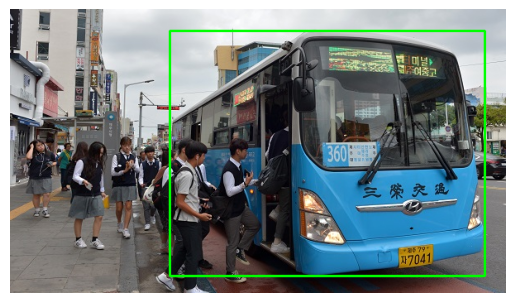

In [151]:
# 그래프 실행
input = VisionState(
    model_path = "model/yolo12n.pt",
    image_path = "./data/bus.png",
    target = "bus",
    threshold = 0.7
)
rs = app.invoke(input = input)

In [152]:
rs

{'model_path': 'model/yolo12n.pt',
 'image_path': './data/bus.png',
 'detections': [{'label': 'bus',
   'confidence': '0.940172',
   'x1': '193',
   'y1': '26',
   'x2': '574',
   'y2': '322'},
  {'label': 'person',
   'confidence': '0.841970',
   'x1': '176',
   'y1': '159',
   'x2': '248',
   'y2': '340'},
  {'label': 'person',
   'confidence': '0.759125',
   'x1': '121',
   'y1': '153',
   'x2': '155',
   'y2': '278'},
  {'label': 'person',
   'confidence': '0.753060',
   'x1': '71',
   'y1': '159',
   'x2': '117',
   'y2': '291'},
  {'label': 'person',
   'confidence': '0.747943',
   'x1': '16',
   'y1': '156',
   'x2': '57',
   'y2': '252'},
  {'label': 'car',
   'confidence': '0.716762',
   'x1': '562',
   'y1': '171',
   'x2': '600',
   'y2': '206'},
  {'label': 'person',
   'confidence': '0.710203',
   'x1': '248',
   'y1': '155',
   'x2': '294',
   'y2': '331'},
  {'label': 'person',
   'confidence': '0.535492',
   'x1': '151',
   'y1': '164',
   'x2': '182',
   'y2': '270'},
